In [9]:
from pathlib import Path

import pandas as pd

from src.data_paths import (
    NEW_EXP_FEATURES_PATH,
    NEW_EXP_IA_ANSWERS_PATH,
    SECOND_TEST_FEATURES_PATH,
    SECOND_TEST_IA_ANSWERS_PATH,
    KNOW_QA_FEATURES_PATH,
    KNOW_QA_IA_ANSWERS_PATH,
)
from src.predictive_modeling.answer_correctness.knowledge_regimes_analysis.comparison_runs import (
    run_regime_split_comparison,
)


## Pick the processed run to analyze

Every experiment run goes through `data_prep_new_exp.ipynb`, each writing its own
model-ready features and keeping its cleaned IA report (which carries `regime` and
`confidence_rating`) next to the raw data:

| run | features | regime / confidence source |
|---|---|---|
| `KnowQA` | `data/KnowQA_runs/L1_model_ready_all_features.csv` | `data_raw/KnowQA/csvs/cleaned/IA_answers.csv` |
| `second_test` | `data/second_test_runs/L1_model_ready_all_features.csv` | `data_raw/second_test/csvs/cleaned/IA_answers.csv` |
| `testrun_QA` | `data/new_exp_try_runs/L1_model_ready_all_features.csv` | `data_raw/testrun_QA/csvs/cleaned/IA_answers.csv` |

`KnowQA` is the first **real** data collection; the other two were the pilot test runs.

Set `RUN_NAME` below; both analyses further down read from it. Run
`data_prep_new_exp.ipynb` with the matching `RUN_NAME` first — that's what produces
these files.


In [10]:
# Which processed run to analyze: "KnowQA" (real data), "second_test" or "testrun_QA" (pilots).
RUN_NAME = "KnowQA"

ANALYSIS_RUNS = {
    "testrun_QA": (NEW_EXP_FEATURES_PATH, NEW_EXP_IA_ANSWERS_PATH),
    "second_test": (SECOND_TEST_FEATURES_PATH, SECOND_TEST_IA_ANSWERS_PATH),
    "KnowQA": (KNOW_QA_FEATURES_PATH, KNOW_QA_IA_ANSWERS_PATH),
}
NEW_FEATURES_PATH, NEW_IA_ANSWERS_PATH = ANALYSIS_RUNS[RUN_NAME]

for _label, _path in [("features", NEW_FEATURES_PATH), ("IA report", NEW_IA_ANSWERS_PATH)]:
    if not _path.exists():
        raise FileNotFoundError(
            f"{_label} for run '{RUN_NAME}' not found at {_path} — "
            f"run data_prep_new_exp.ipynb with RUN_NAME = '{RUN_NAME}' first."
        )

print(f"run:      {RUN_NAME}")
print(f"features: {NEW_FEATURES_PATH}")
print(f"regimes:  {NEW_IA_ANSWERS_PATH}")


run:      KnowQA
features: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data\KnowQA_runs\L1_model_ready_all_features.csv
regimes:  E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data_raw\KnowQA\csvs\cleaned\IA_answers.csv


# Train on L1, test on the new experiment — split by knowledge regime

Fit the logistic-regression correctness model on **all** of L1 and evaluate it
separately on each knowledge regime of the new data — **no knowledge**, **partial
knowledge**, **full knowledge** — to compare how well the model transfers to each
condition, alongside a pooled `all` baseline.

`run_regime_split_comparison` handles the whole thing: it loads the L1 and
new-experiment features, re-attaches the `regime` label from the raw IA report (regime
is dropped during feature building, so it's re-joined on `participant_id` +
`TRIAL_INDEX`), runs the cross-dataset bundle per regime, and returns a comparison
table. It defaults to the current test-run paths but takes DataFrames or paths, so the
same call works unchanged once the full experiment's features are ready.

In [11]:
# Train on all of L1, test per knowledge regime on the selected run's data.
# Per-run confusion / predicted-probability histogram / coefficient / correlation plots
# render inline. Every plot title is prefixed with the regime it refers to (e.g.
# "[no knowledge] — ..."), and the probability histogram shows the model's predicted
# P(correct) split by the true outcome for that regime.
result = run_regime_split_comparison(
    new_features=NEW_FEATURES_PATH,
    regime_source=NEW_IA_ANSWERS_PATH,
    save=False,
    close=False,
)


ValueError: You are trying to merge on int64 and str columns for key 'participant_id'. If you wish to proceed you should use pd.concat

## Results comparison

One row per regime (plus a pooled `all` baseline): test-set size, class balance, and
the L1 model's accuracy / balanced accuracy / F1 on that regime's trials. Sorted by
balanced accuracy within each run.

In [ ]:
# Side-by-side comparison of the L1 model's transfer to each regime.
result["comparison"]

,regime,n_test,n_positive,n_negative,accuracy,balanced_accuracy,macro_f1,weighted_f1,f1_class_0,f1_class_1,roc_auc
0,all,145,113,32,0.862069,0.777102,0.789855,0.858671,0.666667,0.913043,0.903208
1,full knowledge,49,49,0,0.979592,0.979592,0.494845,0.989691,0.000000,0.989691,NaN
2,no knowledge,50,25,25,0.800000,0.800000,0.797078,0.797078,0.772727,0.821429,0.918400
3,partial knowledge,46,39,7,0.804348,0.650183,0.641558,0.809599,0.400000,0.883117,0.750916


# Does the model agree with the participant? — predicted probability vs. self-reported confidence

After every trial the new experiment asks the participant how confident they are in the
answer they just gave (`confidence_rating`, 1–5). The IA report duplicates that
trial-level value across every fixation/IA row of the trial, so it is collapsed back to
one value per `participant_id` + `TRIAL_INDEX` and joined onto the model's per-trial
predictions.

`run_confidence_correlation` reuses the runs computed above (no refitting) and reports
three things, because they can disagree:

* **`pred_prob ~ confidence`** — the headline: does the model's P(correct) rise with the
  participant's confidence? If it does, the eye-movement model is picking up the same
  signal the participant introspects on.
* **`is_correct ~ confidence`** — is the self-report calibrated at all? Without this
  reference a null headline result is uninterpretable (the rating may just be noise).
* **within-participant** — confidence scales are personal, so the pooled correlation
  mixes a within-subject effect with between-subject scale use. The per-participant
  correlations isolate the within-subject part.


Predicted probability vs. self-reported confidence:
              run             comparison   n   mean_x   mean_y  pearson_r    pearson_p  spearman_r   spearman_p  kendall_r    kendall_p
              all pred_prob ~ confidence 145 3.544828 0.725826   0.546469 1.159982e-12    0.534313 4.467771e-12   0.403162 6.613561e-11
   full knowledge pred_prob ~ confidence  49 4.897959 0.892697   0.403323 4.058999e-03    0.344390 1.538745e-02   0.278074 1.861028e-02
     no knowledge pred_prob ~ confidence  50 2.120000 0.576844   0.450350 1.031881e-03    0.454845 9.049065e-04   0.360564 9.649904e-04
partial knowledge pred_prob ~ confidence  46 3.652174 0.710010   0.245564 9.997878e-02    0.179750 2.319559e-01   0.133270 2.415586e-01

Within-participant correlations (run='all'):
run participant_id  n   mean_x   mean_y  pearson_r  pearson_p  spearman_r   spearman_p  kendall_r  kendall_p
all        4000_11 47 3.851064 0.737857   0.460427   0.001128    0.464674 9.999561e-04   0.333321   0.002887
all

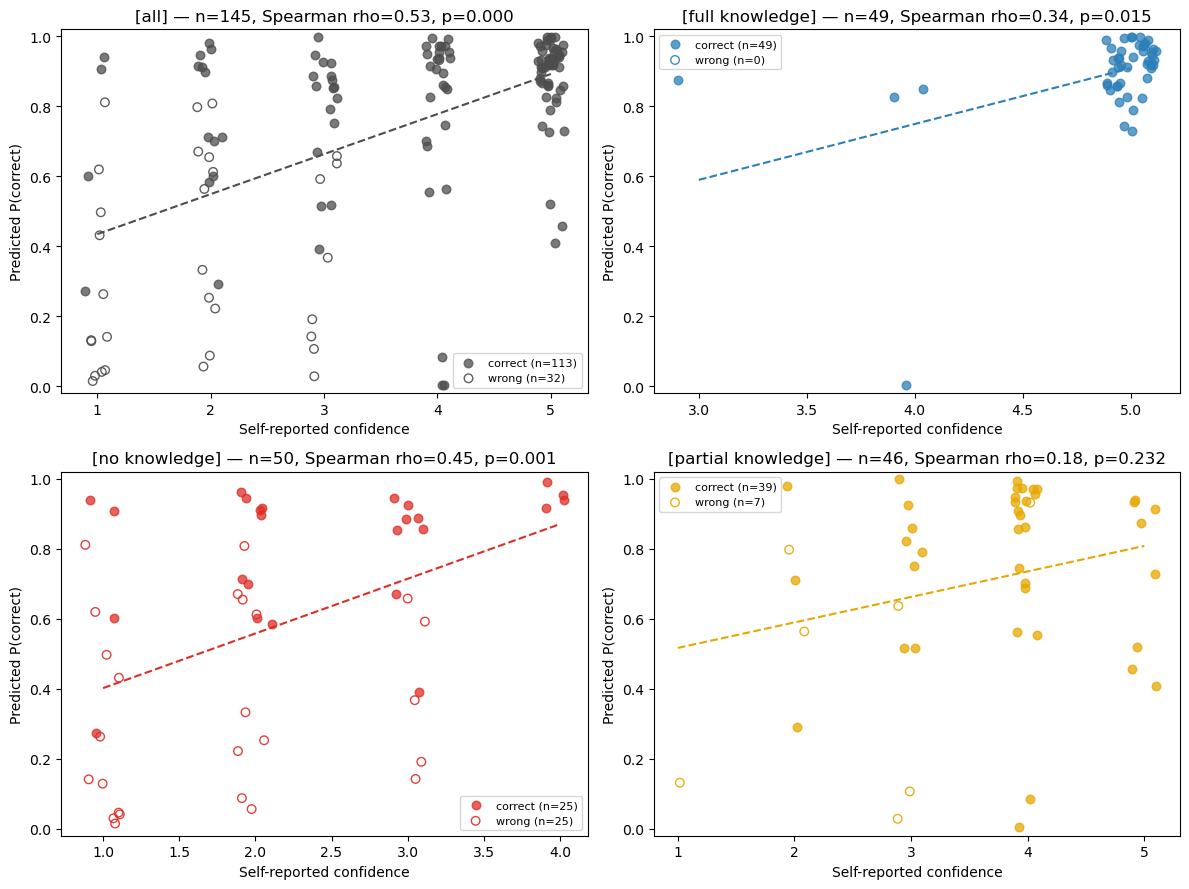

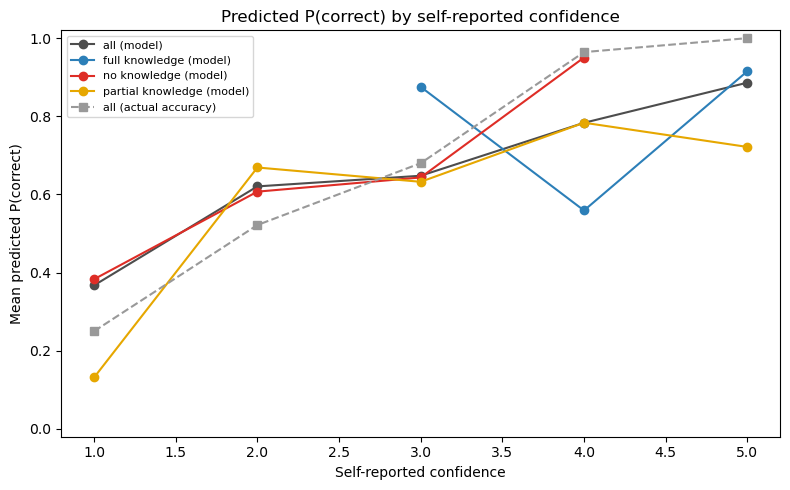

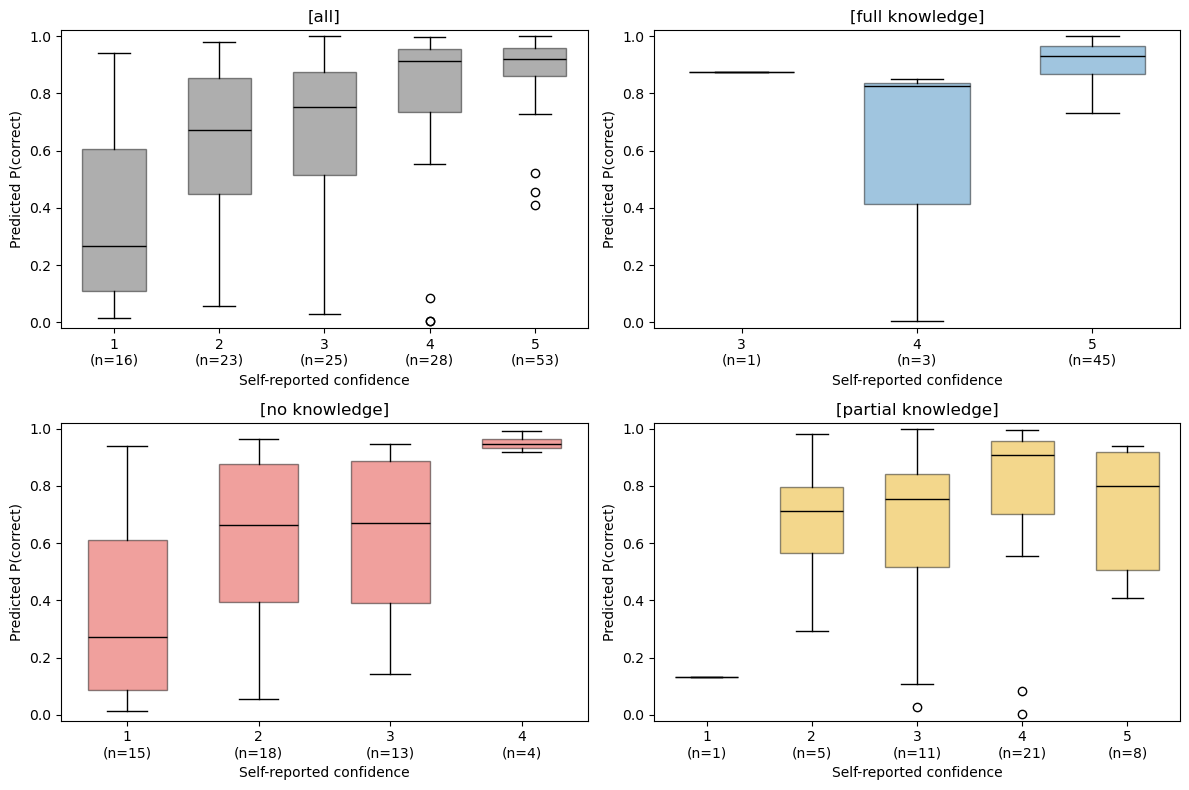

In [ ]:
from src.predictive_modeling.answer_correctness.knowledge_regimes_analysis.confidence_correlation import (
    run_confidence_correlation,
)

# Passing `result` reuses the fitted model and its per-trial predictions from the runs
# above, so nothing is refitted; `confidence_source` is the same cleaned IA report the
# regimes came from. Renders a scatter (confidence vs. P(correct), per regime), the
# mean-P(correct)-by-confidence-level curve against actual accuracy, and per-level
# box plots.
conf = run_confidence_correlation(
    result,
    confidence_source=NEW_IA_ANSWERS_PATH,
    save=False,
    close=False,
)


## Correlation table

Two rows per run. `mean_x` is the mean confidence rating, `mean_y` the mean of whatever
is being correlated against it (predicted P(correct), or the 0/1 outcome). A `nan`
correlation means there was nothing to correlate — e.g. the `full knowledge` trials were
all answered correctly, so `is_correct` has no variance there.

In [ ]:
conf["correlations"]

,run,comparison,n,mean_x,mean_y,pearson_r,pearson_p,spearman_r,spearman_p,kendall_r,kendall_p
0,all,pred_prob ~ confidence,145,3.544828,0.725826,0.546469,1.159982e-12,0.534313,4.467771e-12,0.403162,6.613561e-11
1,all,is_correct ~ confidence,145,3.544828,0.779310,0.611219,3.220395e-16,0.588629,6.902906e-15,0.531941,1.623101e-12
2,full knowledge,pred_prob ~ confidence,49,4.897959,0.892697,0.403323,4.058999e-03,0.344390,1.538745e-02,0.278074,1.861028e-02
3,full knowledge,is_correct ~ confidence,49,4.897959,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,no knowledge,pred_prob ~ confidence,50,2.120000,0.576844,0.450350,1.031881e-03,0.454845,9.049065e-04,0.360564,9.649904e-04
5,no knowledge,is_correct ~ confidence,50,2.120000,0.500000,0.386940,5.504734e-03,0.375117,7.270853e-03,0.347296,8.644163e-03
6,partial knowledge,pred_prob ~ confidence,46,3.652174,0.710010,0.245564,9.997878e-02,0.179750,2.319559e-01,0.133270,2.415586e-01
7,partial knowledge,is_correct ~ confidence,46,3.652174,0.847826,0.476714,8.100115e-04,0.443397,2.026997e-03,0.409368,2.935655e-03


## Per confidence level

One row per (run, rating): how many trials sat at that rating, the model's mean/median
predicted P(correct) there, and the participants' *actual* accuracy. If the model tracks
confidence, `mean_pred_prob` and `accuracy` climb together down the scale.

In [ ]:
conf["by_confidence"]

,run,confidence_rating,n,mean_pred_prob,median_pred_prob,std_pred_prob,accuracy
0,all,1,16,0.367348,0.267855,0.325362,0.250000
1,all,2,23,0.620615,0.670649,0.285096,0.521739
2,all,3,25,0.647863,0.752293,0.292069,0.680000
3,all,4,28,0.783345,0.911958,0.291751,0.964286
4,all,5,53,0.886091,0.921310,0.124812,1.000000
5,full knowledge,3,1,0.875300,0.875300,NaN,1.000000
6,full knowledge,4,3,0.558967,0.825571,0.481732,1.000000
7,full knowledge,5,45,0.915332,0.930919,0.066577,1.000000
8,no knowledge,1,15,0.383065,0.272458,0.330435,0.266667
9,no knowledge,2,18,0.607182,0.662647,0.297476,0.500000


## Within participant

`pred_prob ~ confidence` computed separately inside each participant (pooled `all`
trials), which removes between-subject differences in how the 1–5 scale is used. With
only a handful of participants these are descriptive, not inferential — the p-values are
per-participant and uncorrected.

In [ ]:
conf["by_participant"]

,run,participant_id,n,mean_x,mean_y,pearson_r,pearson_p,spearman_r,spearman_p,kendall_r,kendall_p
0,all,4000_11,47,3.851064,0.737857,0.460427,0.001128,0.464674,9.999561e-04,0.333321,0.002887
1,all,4000_21,50,3.660000,0.689197,0.606590,0.000003,0.573815,1.322229e-05,0.420249,0.000087
2,all,4000_31,48,3.125000,0.752202,0.629844,0.000002,0.640327,9.525619e-07,0.517949,0.000002


# No knowledge, up close: blocks and depth into the article

Two questions about the regime the participant answers with **no context at all**:

**(a) the three blocks separately.** Each session contributes one no-knowledge
block, over its own article batch, so the three blocks are three independent
looks at the same condition. If they agree, the pooled figure is trustworthy;
if one is out of line, that block (or that batch of articles) needs a look.

**(b) does depth into the article predict correctness?** `paragraph_id` is the
paragraph's position in its article, and the questions arrive in ascending
paragraph order within each article (verified: 9/9 article blocks). In this
regime the participant never reads the article, so a rising trend could only
come from information accumulating across the *questions and answer options
themselves* -- each item leaks a little about the article. A flat line means no
such accumulation.

Two caveats to read the second panel with:

* **Paragraph number is confounded with which question was asked.** With
  `question_list = q0`, the list builder's Latin square makes the question index
  a function of the paragraph: `onestopqa_question_id == (paragraph_id - 1) % 3`.
  So a paragraph effect and a question-type effect cannot be separated in this
  data. Running the other two question lists (`q1`, `q2`) would break the tie.
* **Cell sizes get thin fast** -- 9 trials at paragraph 1 but only 1 at
  paragraph 7 (annotated on the chart; the line only joins points with n >= 3).
  The logistic fit uses all 50 trials rather than the per-paragraph means, so it
  is the more reliable summary.

The depth question is asked of **both** regimes, because they test different
mechanisms. With no knowledge, a trend could only come from the items leaking
information. With partial knowledge the participant has actually read paragraphs
1..N-1 of that article in the earlier trials of the block, so a trend there would
be genuine accumulated context. The `regime x paragraph` interaction is the test
that separates the two.

Chance is 25% (four options) and full knowledge sits at 100% throughout, so
partial knowledge is the informative comparison.


(a) NO KNOWLEDGE, THE THREE BLOCKS SEPARATELY
 article_batch session_id  n  correct  accuracy    lo    hi p_vs_chance
             1    4000_11 15        8     0.533 0.301 0.752      0.0173
             2    4000_21 18        8     0.444 0.246 0.663      0.0569
             3    4000_31 17        9     0.529 0.310 0.738      0.0124

pooled  25/50 = 0.500 [0.366, 0.634]   vs chance 0.25: p = 1.23e-04
do the blocks differ from each other?  chi2(2) = 0.35, p = 0.840

(b) DEPTH INTO THE ARTICLE vs CORRECTNESS
accuracy by paragraph -- no knowledge:
 paragraph_id  n  correct  accuracy    lo    hi
            1  9        3     0.333 0.121 0.646
            2  9        5     0.556 0.267 0.811
            3  9        5     0.556 0.267 0.811
            4  9        5     0.556 0.267 0.811
            5  7        3     0.429 0.158 0.750
            6  6        3     0.500 0.188 0.812
            7  1        1     1.000 0.207 1.000

accuracy by paragraph -- partial knowledge:
 paragraph_id  n  cor

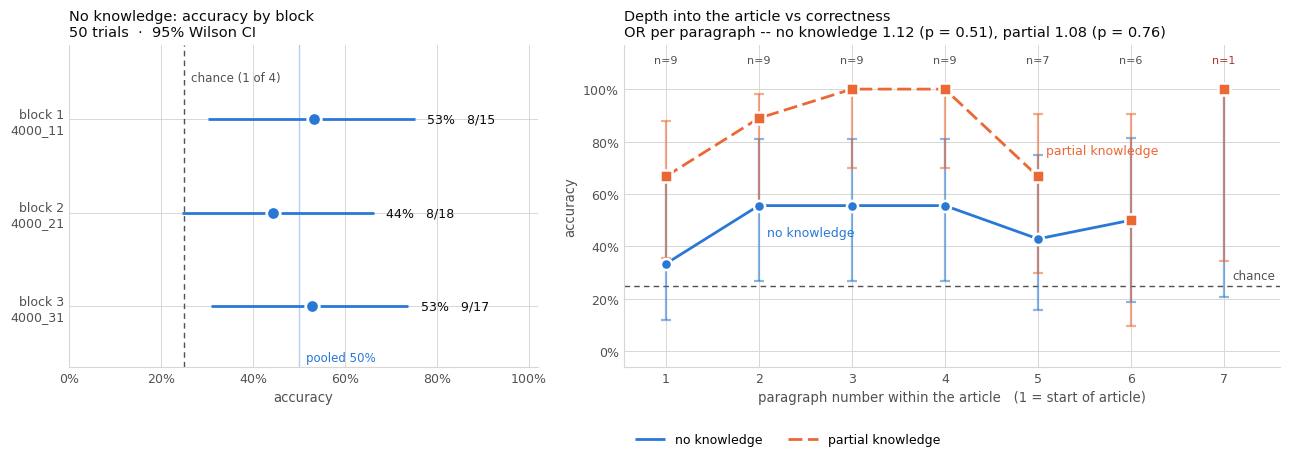

In [13]:
# No-knowledge regime: per-block performance, and accuracy vs depth into the article.
# Reads the cleaned IA report of the selected RUN_NAME (see the run switch above).
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# Categorical slots 1-2 of the validated reference palette; marker and dash
# carry series identity alongside hue, so colour is never the only cue.
C_NK, C_PK = "#2a78d6", "#eb6834"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#d8d7d2"
CHANCE = 0.25       # four answer options
MIN_N = 3           # thinner points are plotted but not joined by the line

_cols = ["session_id", "trial_number", "practice_trial", "regime", "article_batch",
         "article_id", "paragraph_id", "onestopqa_question_id",
         "correct_answer_position", "selected_answer_position"]
_trials = (pd.read_csv(NEW_IA_ANSWERS_PATH, low_memory=False, usecols=_cols)
           .drop_duplicates(["session_id", "trial_number"]))
_trials = _trials[_trials["practice_trial"] == 0].copy()
_trials["is_correct"] = (
    _trials["correct_answer_position"] == _trials["selected_answer_position"]
).astype(int)
nk = _trials[_trials["regime"] == "no knowledge"].copy()


def wilson(k, n, z=1.96):
    """Wilson score interval -- stays sensible where n is as small as 1."""
    if n == 0:
        return (np.nan, np.nan)
    p, d = k / n, 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / d
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / d
    return (max(centre - half, 0.0), min(centre + half, 1.0))


def with_ci(g):
    g = g.copy()
    g["accuracy"] = g["correct"] / g["n"]
    g[["lo", "hi"]] = g.apply(lambda r: pd.Series(wilson(r["correct"], r["n"])), axis=1)
    return g


# ----------------------------------------------------------- (a) three blocks
blocks = with_ci(
    nk.groupby(["article_batch", "session_id"])["is_correct"]
      .agg(n="size", correct="sum").reset_index().sort_values("article_batch"))
blocks["p_vs_chance"] = blocks.apply(
    lambda r: stats.binomtest(int(r["correct"]), int(r["n"]), CHANCE,
                              alternative="greater").pvalue, axis=1)

pooled_k, pooled_n = int(nk["is_correct"].sum()), len(nk)
pooled_lo, pooled_hi = wilson(pooled_k, pooled_n)
pooled_p = stats.binomtest(pooled_k, pooled_n, CHANCE, alternative="greater").pvalue
chi2, p_hom, dof, _ = stats.chi2_contingency(
    np.array([blocks["correct"].values, (blocks["n"] - blocks["correct"]).values]))

print("=" * 74)
print("(a) NO KNOWLEDGE, THE THREE BLOCKS SEPARATELY")
print("=" * 74)
print(blocks.assign(accuracy=blocks["accuracy"].round(3),
                    lo=blocks["lo"].round(3), hi=blocks["hi"].round(3),
                    p_vs_chance=blocks["p_vs_chance"].map("{:.4f}".format)
                    )[["article_batch", "session_id", "n", "correct", "accuracy",
                       "lo", "hi", "p_vs_chance"]].to_string(index=False))
print(f"\npooled  {pooled_k}/{pooled_n} = {pooled_k / pooled_n:.3f} "
      f"[{pooled_lo:.3f}, {pooled_hi:.3f}]   vs chance {CHANCE}: p = {pooled_p:.2e}")
print(f"do the blocks differ from each other?  chi2({dof}) = {chi2:.2f}, p = {p_hom:.3f}")

# ------------------------------------------------------ (b) depth in article
nk_p = with_ci(nk.groupby("paragraph_id")["is_correct"]
               .agg(n="size", correct="sum").reset_index())
pk_p = with_ci(_trials[_trials["regime"] == "partial knowledge"]
               .groupby("paragraph_id")["is_correct"]
               .agg(n="size", correct="sum").reset_index())
def depth_trend(d, label):
    """Logistic slope of correctness on paragraph number, plus a rank check."""
    m = sm.Logit(d["is_correct"],
                 sm.add_constant(d["paragraph_id"].astype(float))).fit(disp=0)
    b = m.params["paragraph_id"]
    ci = m.conf_int().loc["paragraph_id"]
    rho = stats.spearmanr(d["paragraph_id"], d["is_correct"])
    return {
        "regime": label, "n": len(d), "accuracy": round(d["is_correct"].mean(), 3),
        "OR_per_paragraph": round(float(np.exp(b)), 2),
        "OR_lo": round(float(np.exp(ci[0])), 2),
        "OR_hi": round(float(np.exp(ci[1])), 2),
        "p": round(float(m.pvalues["paragraph_id"]), 3),
        "spearman_rho": round(float(rho.statistic), 3),
        "spearman_p": round(float(rho.pvalue), 3),
    }


pk = _trials[_trials["regime"] == "partial knowledge"].copy()
trend = pd.DataFrame([depth_trend(nk, "no knowledge"),
                      depth_trend(pk, "partial knowledge")])
odds = float(trend.loc[0, "OR_per_paragraph"])
p_slope = float(trend.loc[0, "p"])
odds_pk = float(trend.loc[1, "OR_per_paragraph"])
p_slope_pk = float(trend.loc[1, "p"])

# Does depth matter more when the participant actually reads a paragraph?
# The interaction is the test that separates "cumulative reading" from
# "information leaking out of the questions themselves".
_both = pd.concat([nk, pk]).copy()
_both["read"] = (_both["regime"] == "partial knowledge").astype(int)
_both["p_c"] = _both["paragraph_id"] - _both["paragraph_id"].mean()
_inter = smf.logit("is_correct ~ p_c * read", data=_both).fit(disp=0)

# a coarser, better-powered split than seven thin per-paragraph cells
_both["depth_half"] = np.where(_both["paragraph_id"] <= 3, "1-3 (early)", "4+ (later)")
halves = (_both.groupby(["regime", "depth_half"])["is_correct"]
          .agg(n="size", correct="sum").reset_index())
halves["accuracy"] = (halves["correct"] / halves["n"]).round(3)

# sanity-check the confound flagged in the markdown above
_confounded = int((nk["onestopqa_question_id"]
                   == (nk["paragraph_id"] - 1) % 3).sum())

print()
print("=" * 74)
print("(b) DEPTH INTO THE ARTICLE vs CORRECTNESS")
print("=" * 74)
print("accuracy by paragraph -- no knowledge:")
print(nk_p.assign(accuracy=nk_p["accuracy"].round(3), lo=nk_p["lo"].round(3),
                  hi=nk_p["hi"].round(3)).to_string(index=False))
print("\naccuracy by paragraph -- partial knowledge:")
print(pk_p.assign(accuracy=pk_p["accuracy"].round(3), lo=pk_p["lo"].round(3),
                  hi=pk_p["hi"].round(3)).to_string(index=False))
print("\nlogistic  is_correct ~ paragraph_id,  per regime:")
print(trend.to_string(index=False))
print("\nearly vs later paragraphs (better powered than 7 thin cells):")
print(halves.to_string(index=False))
print(f"\nregime x paragraph interaction: coef {_inter.params['p_c:read']:+.3f}, "
      f"p = {_inter.pvalues['p_c:read']:.3f}")
print("  (tests whether depth helps more when a paragraph is actually read)")
print(f"\nconfound check: question index == (paragraph-1)%3 on "
      f"{_confounded}/{len(nk)} trials")

# -------------------------------------------------------------------- figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8),
                               gridspec_kw={"width_ratios": [1, 1.4]})

# (a) one series -> one hue and no legend; the title names it
y = np.arange(len(blocks))
ax1.axvline(CHANCE, color=INK_2, lw=1, ls=(0, (4, 3)), zorder=1)
ax1.annotate("chance (1 of 4)", (CHANCE, -0.45), xytext=(5, 0),
             textcoords="offset points", fontsize=8.5, color=INK_2, va="center")
ax1.axvline(pooled_k / pooled_n, color=C_NK, lw=1, alpha=0.35, zorder=1)
ax1.annotate(f"pooled {pooled_k / pooled_n:.0%}",
             (pooled_k / pooled_n, len(blocks) - 0.45), xytext=(5, 0),
             textcoords="offset points", fontsize=8.5, color=C_NK, va="center")
ax1.hlines(y, blocks["lo"], blocks["hi"], color=C_NK, lw=2, zorder=2)
ax1.scatter(blocks["accuracy"], y, s=95, color=C_NK, zorder=3,
            edgecolor="white", linewidth=2)
for yi, r in zip(y, blocks.itertuples()):
    ax1.annotate(f"{r.accuracy:.0%}   {r.correct}/{r.n}", (r.hi, yi), xytext=(9, 0),
                 textcoords="offset points", fontsize=9, color=INK, va="center")
ax1.set_yticks(y)
ax1.set_yticklabels([f"block {b}\n{s}" for b, s in
                     zip(blocks["article_batch"], blocks["session_id"])], fontsize=9)
ax1.set_ylim(len(blocks) - 0.35, -0.8)     # block 1 reads at the top
ax1.set_xlim(0, 1.02)
ax1.set_xlabel("accuracy", fontsize=9.5, color=INK_2)
ax1.set_title("No knowledge: accuracy by block\n"
              f"{pooled_n} trials  \u00b7  95% Wilson CI",
              fontsize=10.5, color=INK, loc="left")
ax1.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")

# (b) discrete x -> error bars rather than a band that would imply interpolation
for g, colour, marker, dash, label, at, dy in [
    (nk_p, C_NK, "o", (0, ()), "no knowledge", 2, -22),
    (pk_p, C_PK, "s", (0, (5, 2)), "partial knowledge", 5, 16),
]:
    joined = g[g["n"] >= MIN_N]
    ax2.errorbar(g["paragraph_id"], g["accuracy"],
                 yerr=[g["accuracy"] - g["lo"], g["hi"] - g["accuracy"]],
                 fmt="none", ecolor=colour, elinewidth=1.6, capsize=3.5,
                 capthick=1.6, alpha=0.55, zorder=2)
    ax2.plot(joined["paragraph_id"], joined["accuracy"], color=colour, lw=2,
             ls=dash, zorder=3, label=label)
    ax2.plot(g["paragraph_id"], g["accuracy"], color=colour, ls="none",
             marker=marker, ms=8, mec="white", mew=1.8, zorder=4)
    row = g[g["paragraph_id"] == at]
    if len(row):
        row = row.iloc[0]
        ax2.annotate(label, (row["paragraph_id"], row["accuracy"]), xytext=(6, dy),
                     textcoords="offset points", fontsize=9, color=colour)

ax2.axhline(CHANCE, color=INK_2, lw=1, ls=(0, (4, 3)), zorder=1)
_xmax = float(nk_p["paragraph_id"].max())
ax2.annotate("chance", (_xmax + 0.55, CHANCE), xytext=(0, 5),
             textcoords="offset points", fontsize=8.5, color=INK_2, ha="right")
for r in nk_p.itertuples():          # n swings from 9 down to 1 -- say so
    ax2.annotate(f"n={r.n}", (r.paragraph_id, 1.10), fontsize=8, ha="center",
                 color=INK_2 if r.n >= MIN_N else "#a33")
ax2.set_xlabel("paragraph number within the article   (1 = start of article)",
               fontsize=9.5, color=INK_2)
ax2.set_ylabel("accuracy", fontsize=9.5, color=INK_2)
ax2.set_ylim(-0.06, 1.17)
ax2.set_xlim(0.55, _xmax + 0.6)
ax2.set_xticks(range(1, int(_xmax) + 1))
ax2.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax2.set_title("Depth into the article vs correctness\n"
              f"OR per paragraph -- no knowledge {odds:.2f} (p = {p_slope:.2f}), "
              f"partial {odds_pk:.2f} (p = {p_slope_pk:.2f})",
              fontsize=10.5, color=INK, loc="left")
ax2.legend(frameon=False, fontsize=9, ncols=2, handlelength=2.4,
           loc="upper left", bbox_to_anchor=(0.0, -0.17))

for ax in (ax1, ax2):
    ax.grid(color=GRID, lw=0.7, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_2, labelsize=9, length=0)

fig.tight_layout()
plt.show()
